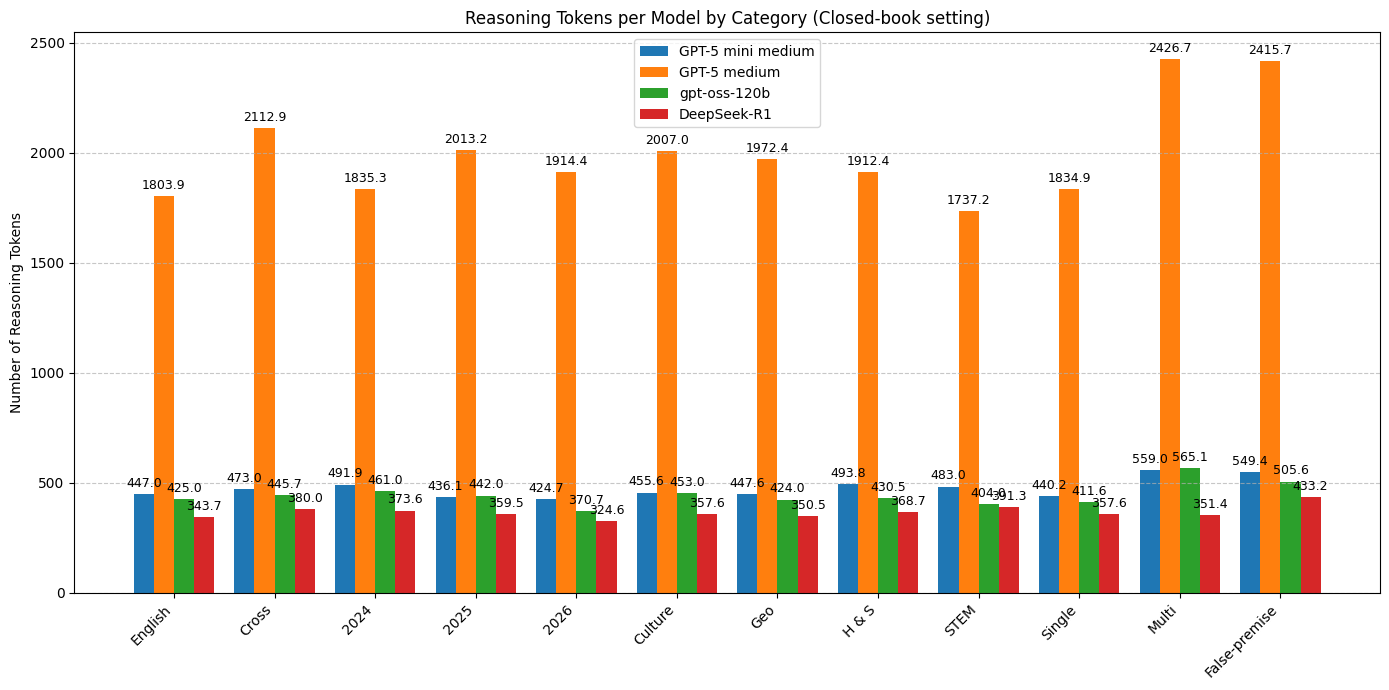

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load Data
# Assuming the CSV has the Model names in the first column
# format: Model, English, Multilingual, 2024...
# index_col=0 sets the first column (Model names) as the index
df = pd.read_csv('./data/reasoning_tokens_visualization/closedbook.csv', index_col=0)

# 2. Extract Data
categories = df.columns
models = df.index
n_models = len(models)
n_categories = len(categories)

# 3. Bar Chart Setup
x = np.arange(n_categories)  # Label locations
total_width = 0.8            # Total width for the group of bars (leaving 0.2 gap)
bar_width = total_width / n_models

fig, ax = plt.subplots(figsize=(14, 7))

# 4. Helper function for labels (from your original code)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# 5. Plotting Loop (Dynamic for any number of models)
for i, model in enumerate(models):
    # Calculate the offset for this specific bar
    # (i - n_models / 2) centers the group around the tick mark
    # + (bar_width / 2) adjusts for the fact that bars are drawn from left edge
    offset = (i - n_models / 2) * bar_width + (bar_width / 2)
    
    values = df.loc[model]
    
    # Plot bar
    rects = ax.bar(x + offset, values, bar_width, label=model)
    
    # Add values on top
    autolabel(rects)

# 6. Formatting
ax.set_ylabel('Number of Reasoning Tokens')
ax.set_title('Reasoning Tokens per Model by Category (Closed-book setting)')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("ReasoningTokensVis.pdf")
plt.show()